#Mi primer notebook
# Olivia Weihmuller

<h1 align="center">TSO: Primeros pasos de simulación</h1>

### En este trabajo buscamos familiarizarnos con la herramienta Jupyter a través de la generación y el análisis de señales senoidales. Para eso, se creó una función que permite modificar diferentes parámetros de la señal, como la amplitud máxima, el valor medio, la frecuencia, la fase, la cantidad de muestras y la frecuencia de muestreo. El objtivo principal es modelar el proceso de digitalizacion de un ADC. A partir de la ecuacion de la senoide: 
##$$x[n] = V_{\text{max}} \cdot \sin(2\pi \cdot f \cdot t_n + \phi) + DC$$


#### Para analizar el comportamiento de la señal digitalizada, se realizaron distintos experimentos manteniendo fija la frecuencia de muestreo en: fs=1000 Hz y manteniendo fija la cantidad de muestras N= 1000.
#### La frecuencia de la senoidal se fue modificando utilizando los siguientes valores: 500Hz, 999 Hz, 1001 Hz y 2001 Hz. El objetivo fue observar el comportamiento de la senal al variar su frecuencia en relacion con la frecuencia de Nyquist. Frecuencia_nyquist = fs/2 

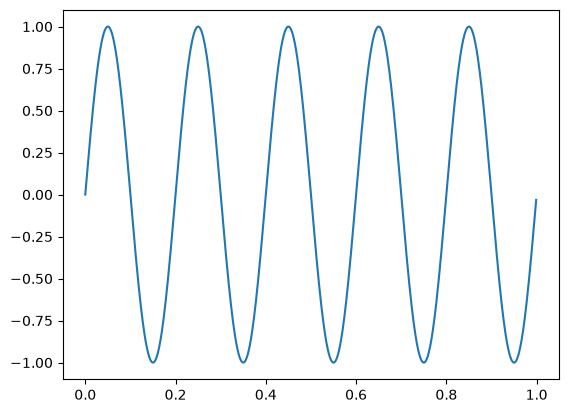

In [45]:


import matplotlib.pyplot as plt
import numpy as np

#%% definicioes
#modalizar como un adc digitaliza una senoideal q la puedo estar generado por u generador de senales

fs = 1000 #Hz, muestras por segundo
N = 1000 #muestras


#%% funciones

def mi_funcion_sen( vmax = 1, dc = 0, ff = 1, ph=0, nn = N, fs = fs):
     #valor medio de una senal = dc (si no lo pasa toma x defecto el 0)

   nn = np.arange (nn) #calcula cantidad de valores, algo asi
   xx = vmax * np.sin (2 * np.pi * ff * nn/fs + ph) +dc
   tt = nn/fs  # tiempo de cada muestra
    
   # hasta acá
   return(tt, xx)
# N ES LA CANTIDAD DE MUESTRAS Q LE PASAS A LA FUCNION
#nn NUMERO DE muestras q se generan

#%%  comienzo de mi script

ff=5
vmax=1.5
dc=2

ph= 0
# periodo de una senal vale 1/10, en mi espacio N muestras 10 ciclos completos
# cada 1/fs se calcula una muestra
nn = np.arange (N) # genera una secuencia de numeros
xx = vmax * np.sin (2 * np.pi * ff * nn/fs + ph)

tt = nn/fs  # tiempo de cada muestra

tt,xx = mi_funcion_sen(vmax = 1, dc=0, ff=5, ph=0, nn=N, fs=1000)
plt.plot(tt,xx)

#tt, xx = mi_funcion_sen( vmax = 1, dc = 0, ff = 1, ph=0, N = N, fs = fs)



Pruebo con otras frecuencias

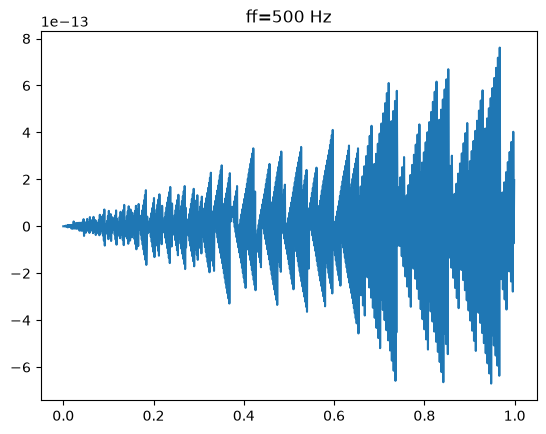

In [46]:

tt, xx = mi_funcion_sen(vmax=1, dc=0, ff=500, ph=0, nn=N, fs=fs)
plt.figure()
plt.title('ff=500 Hz')
plt.plot(tt,xx)



Este caso al elegir 500Hz, la frecuencia de Nyquist ocurre algo diferente. 
$$x[n] = V_{\text{max}} \cdot \sin\left(2\pi \cdot 500 \cdot \frac{n}{1000} + 0\right)$$
Por lo que queda $\sin(\pi \cdot n)$, cuyo resultado es siempre $0$. Por este motivo, se puede observar en el gráfico que la señal es prácticamente cero. 

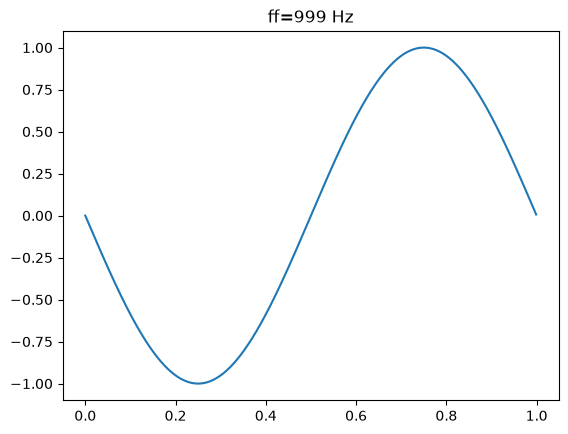

In [47]:
tt, xx = mi_funcion_sen(vmax=1, dc=0, ff=999, ph=0, nn=N, fs=fs)
plt.figure()
plt.title('ff=999 Hz')
plt.plot(tt,xx)



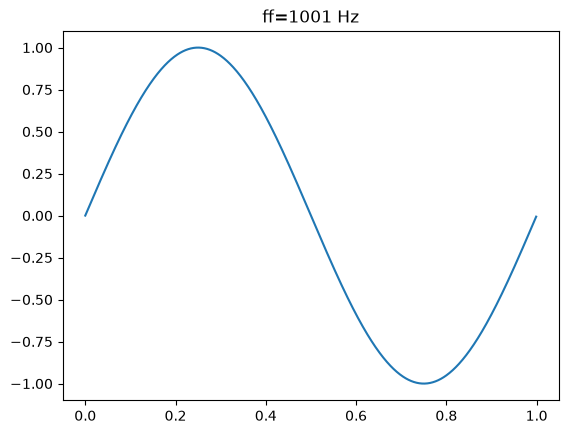

In [48]:
tt, xx = mi_funcion_sen(vmax=1, dc=0, ff=1001, ph=0, nn=N, fs=fs)
plt.figure()
plt.title('ff=1001 Hz')
plt.plot(tt,xx)



Se observar que, para las dos frecuencias de f= 999 Hz y f=1001 Hz, ambdas son mayores que la frecuencia de Nyquist (f=500 Hz). En los dos tienen se obtiene una senal de la misma frecuencia aparente, pero con un desfase entre ellas. Esto se debe a que siguen una relación que calcula la frecuencia que va a ver la computadora. La frecuencia que se observa despues del muestreo esta relacionada con la distancia entre la frecuencia de la senal y el múltiplo más cercano de la frecuencia de muestreo. En ambos casos ese valor es 1000. Por lo tanto, ambas senales se observan como una senal de la misma frecuencia. Pero como una frecuencia esta debajo de 1000 Hz y la otra por encima, presentan un desfase lo que explica la diferencia de fase que se observa en los gráficos.

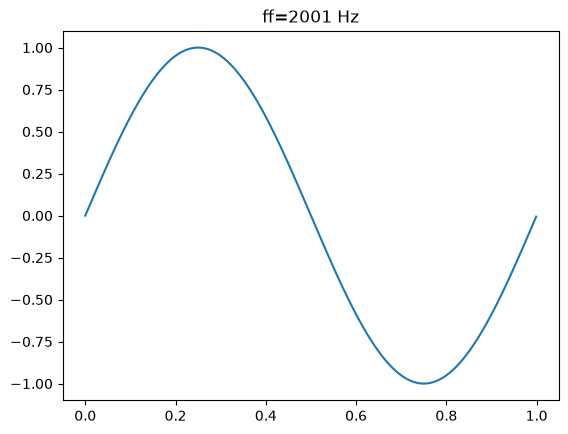

In [49]:
tt, xx = mi_funcion_sen(vmax=1, dc=0, ff=2001, ph=0, nn=N, fs=fs)
plt.figure()
plt.title('ff=2001 Hz')
plt.plot(tt,xx)

Para el último caso, se puede observar que el gráfico dió identico al de f = 1001 Hz. Debido a que, al usar una frecuencia de 2001 Hz, el multiplo más cercano a la frecuencia de muestreo es 2000 por lo que queda la misma relacion vista anteriormente (1001 Hz). 

# Conclusion

En este trabajo se utilizó una función en Python para generar señales senoidales. Se varió la frecuencia de la señal para analizar el efecto del muestreo. Se pudo observar la relación entre la frecuencia de la señal y la frecuencia de muestreo, y cómo influye cuando la señal alcanza o supera la frecuencia de Nyquist.
